# Example 4: Spatial integration and optimization of a plug-flow reactor

This notebook contains the reproducible Python implementation for Example 4 of
*Model Reactors and Their Design Equations*. A steady isothermal plug-flow reactor
is integrated along its axial coordinate. The desired intermediate product $A_2$ is
formed in the reaction network

$$A_1 \xrightarrow{r_1} A_2 \xrightarrow{r_2} A_3, \qquad
A_2 \xrightarrow{r_3} A_4.$$

The notebook demonstrates:

1. spatial integration of the reactor model as an initial-value problem,
2. optimization of reactor length at fixed temperature,
3. simultaneous optimization of reactor length and temperature,
4. a mass-closure check, and
5. export of publication figures and PGFPlots data.

In [8]:
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution, minimize_scalar

# Publication settings shared with Examples 5 and 6. PDF is the primary
# vector format; the 600-dpi PNG export is retained only as a fallback.
plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (7.0, 4.8),
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.usetex": True,
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "grid.linewidth": 0.5,
    "lines.linewidth": 1.5,
    "axes.unicode_minus": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

FIGURE_DIR = Path("publication_figures")
FIGURE_DIR.mkdir(exist_ok=True)
PGF_DATA_DIR = FIGURE_DIR / "pgfplots_data"
PGF_DATA_DIR.mkdir(exist_ok=True)


def save_publication_figure(fig, stem):
    """Write a vector PDF and a 600-dpi raster fallback."""
    fig.savefig(FIGURE_DIR / f"{stem}.pdf", format="pdf", facecolor="white")
    fig.savefig(FIGURE_DIR / f"{stem}.png", format="png", dpi=600, facecolor="white")

## Model equations

Under steady, isothermal plug-flow conditions, the axial material balances are

$$
\frac{\mathrm{d}c_1}{\mathrm{d}z}=-\frac{A_R}{\dot V}r_1,
\quad
\frac{\mathrm{d}c_2}{\mathrm{d}z}=\frac{A_R}{\dot V}(r_1-r_2-r_3),
\quad
\frac{\mathrm{d}c_3}{\mathrm{d}z}=\frac{A_R}{\dot V}r_2,
\quad
\frac{\mathrm{d}c_4}{\mathrm{d}z}=\frac{A_R}{\dot V}r_3.
$$

The reaction rates follow Arrhenius-type power laws. Concentrations at $z=0$
provide the initial values for integration along the reactor coordinate.

In [9]:
@dataclass(frozen=True)
class ReactorParameters:
    """Constant parameters for Example 4."""

    # Inlet concentrations / mol m^-3
    c_1_in: float = 10.0
    c_2_in: float = 0.0
    c_3_in: float = 0.0
    c_4_in: float = 0.0

    # Arrhenius pre-exponential factors / s^-1
    k10: float = 5.4e10
    k20: float = 4.6e17
    k30: float = 5.0e7

    # Activation energies / J mol^-1
    E_A1: float = 7.5e4
    E_A2: float = 1.2e5
    E_A3: float = 5.5e4

    # Reaction orders
    n1: float = 1.1
    n2: float = 1.0
    n3: float = 1.0

    R: float = 8.3145       # gas constant / J mol^-1 K^-1
    T: float = 330.0        # nominal reactor temperature / K
    A_R: float = 0.1        # cross-sectional area / m^2
    q: float = 0.1          # volumetric flow rate / m^3 s^-1

    @property
    def inlet_vector(self):
        return np.array([self.c_1_in, self.c_2_in, self.c_3_in, self.c_4_in])

    @property
    def axial_factor(self):
        return self.A_R / self.q


p = ReactorParameters()
p

ReactorParameters(c_1_in=10.0, c_2_in=0.0, c_3_in=0.0, c_4_in=0.0, k10=54000000000.0, k20=4.6e+17, k30=50000000.0, E_A1=75000.0, E_A2=120000.0, E_A3=55000.0, n1=1.1, n2=1.0, n3=1.0, R=8.3145, T=330.0, A_R=0.1, q=0.1)

In [10]:
def reaction_rates(c, T, p):
    """Return r1, r2, and r3 in mol m^-3 s^-1."""
    c_1, c_2, _, _ = c
    c_1_safe = max(c_1, 0.0)
    c_2_safe = max(c_2, 0.0)
    k1 = p.k10 * np.exp(-p.E_A1 / (p.R * T))
    k2 = p.k20 * np.exp(-p.E_A2 / (p.R * T))
    k3 = p.k30 * np.exp(-p.E_A3 / (p.R * T))
    return (
        k1 * c_1_safe**p.n1,
        k2 * c_2_safe**p.n2,
        k3 * c_2_safe**p.n3,
    )


def rhs_axial_balances(z, c, p, T=None):
    """Right-hand side dc/dz of the spatial initial-value problem."""
    del z
    if T is None:
        T = p.T
    r1, r2, r3 = reaction_rates(c, T, p)
    factor = p.axial_factor
    return np.array([
        -factor * r1,
        factor * (r1 - r2 - r3),
        factor * r2,
        factor * r3,
    ])


def solve_profile(L_R, p, T=None, *, dense_output=True,
                  rtol=1e-10, atol=1e-12, max_step=0.05):
    """Integrate the concentration profile from z=0 to z=L_R."""
    if T is None:
        T = p.T
    return solve_ivp(
        lambda z, c: rhs_axial_balances(z, c, p, T),
        (0.0, float(L_R)),
        p.inlet_vector,
        method="RK45",
        dense_output=dense_output,
        rtol=rtol,
        atol=atol,
        max_step=max_step,
    )


def mass_closure(c, p):
    return np.sum(c, axis=0) - p.c_1_in

## 1 Spatial integration at fixed temperature

The reactor is integrated over $0\le z\le 50\,\mathrm{m}$ at
$T=330\,\mathrm{K}$. The tight tolerances make the numerical mass-closure
check meaningful relative to the displayed concentrations.

In [11]:
L_R_plot = 50.0
z = np.linspace(0.0, L_R_plot, 801)
solution = solve_profile(L_R_plot, p, dense_output=True)
if not solution.success:
    raise RuntimeError(solution.message)

concentrations = solution.sol(z)
closure = mass_closure(concentrations, p)
c_out = concentrations[:, -1]

print(f"ODE solver success: {solution.success}")
print(f"Function evaluations: {solution.nfev}")
print("Outlet concentrations at L_R = 50 m / mol m^-3:")
for index, value in enumerate(c_out, start=1):
    print(f"  c_{index} = {value:.6f}")
print(f"Maximum absolute mass-closure error: {np.max(np.abs(closure)):.3e} mol m^-3")

ODE solver success: True
Function evaluations: 6014
Outlet concentrations at L_R = 50 m / mol m^-3:
  c_1 = 0.231581
  c_2 = 0.200364
  c_3 = 3.074989
  c_4 = 6.493066
Maximum absolute mass-closure error: 1.776e-14 mol m^-3


## 2 Reactor-length optimization

At fixed temperature, the design problem maximizes the outlet concentration
of the intermediate product $A_2$ with respect to reactor length. It is solved
as a bounded scalar minimization of $-c_2(L_R)$.

In [12]:
def objective_negative_c2_at_length(L_R, p, T=None):
    solution = solve_profile(L_R, p, T, dense_output=False)
    if not solution.success:
        raise RuntimeError(solution.message)
    return -float(solution.y[1, -1])


def optimize_length_fixed_temperature(p, T=None, bounds=(0.0, 50.0)):
    if T is None:
        T = p.T
    result = minimize_scalar(
        lambda L_R: objective_negative_c2_at_length(L_R, p, T),
        bounds=bounds,
        method="bounded",
        options={"xatol": 1e-10},
    )
    return {
        "L_R_star": float(result.x),
        "T_star": float(T),
        "c_2_star": float(-result.fun),
        "success": bool(result.success),
    }


optimum_length = optimize_length_fixed_temperature(p)
print(f"Optimization success: {optimum_length['success']}")
print(f"L_R* = {optimum_length['L_R_star']:.6f} m")
print(f"T    = {optimum_length['T_star']:.6f} K")
print(f"c_2* = {optimum_length['c_2_star']:.6f} mol m^-3")

Optimization success: True
L_R* = 8.427211 m
T    = 330.000000 K
c_2* = 2.784402 mol m^-3


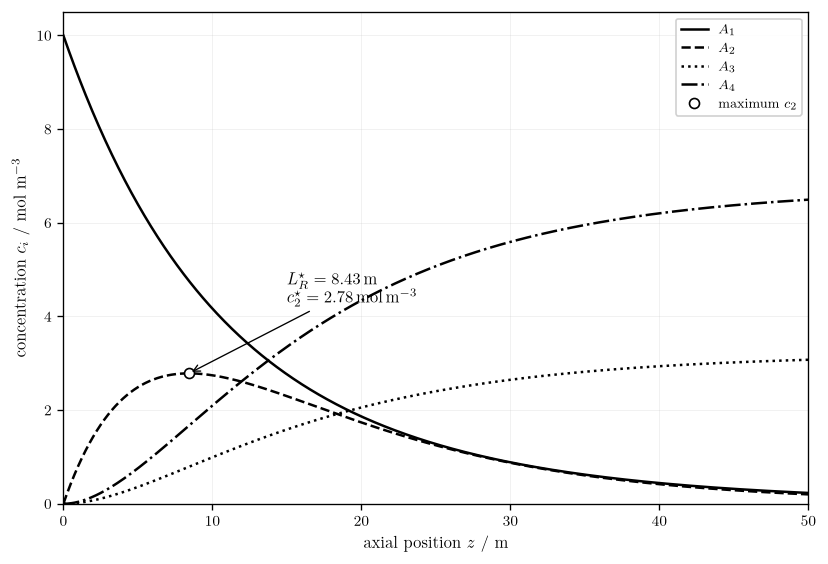

Publication files written to /Users/jens/ownCloud_TUC/02_research/02_publications/30_miscellaneous/01_Ullmanns/00_Reaktor_Modellierung/Manuskript/Python_code_Ex_4_5_6/publication_figures


In [13]:
# Notebook preview and publication fallback figure.
fig, ax = plt.subplots(figsize=(7.0, 4.8))
line_styles = ["-", "--", ":", "-."]
for index, line_style in enumerate(line_styles):
    ax.plot(z, concentrations[index], color="black", linestyle=line_style,
            label=fr"$A_{{{index + 1}}}$")

z_star = optimum_length["L_R_star"]
c_2_star = optimum_length["c_2_star"]
ax.plot(z_star, c_2_star, marker="o", markerfacecolor="white",
        markeredgecolor="black", markeredgewidth=1.0, linestyle="none",
        label=r"maximum $c_2$")
ax.annotate(
    rf"$L_R^\star={z_star:.2f}\,\mathrm{{m}}$" + "\n" +
    rf"$c_2^\star={c_2_star:.2f}\,\mathrm{{mol\,m^{{-3}}}}$",
    xy=(z_star, c_2_star), xytext=(15.0, 4.3),
    arrowprops={"arrowstyle": "->", "linewidth": 0.8, "color": "black"},
)
ax.set_xlabel(r"axial position $z$ / m")
ax.set_ylabel(r"concentration $c_i$ / mol m$^{-3}$")
ax.set_xlim(0.0, 50.0)
ax.set_ylim(0.0, 10.5)
ax.legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.9)
fig.tight_layout()
save_publication_figure(fig, "ex4_concentration_profiles")
plt.show()

# Numerical data consumed directly by the native PGFPlots manuscript figure.
np.savetxt(
    PGF_DATA_DIR / "ex4_concentration_profiles.dat",
    np.column_stack([z, concentrations.T]),
    header="z c1 c2 c3 c4", comments="", fmt="%.10g",
)
np.savetxt(
    PGF_DATA_DIR / "ex4_optimum.dat",
    np.array([[z_star, c_2_star]]),
    header="z c2", comments="", fmt="%.10g",
)
print("Publication files written to", FIGURE_DIR.resolve())

## 3 Joint length-temperature optimization

The second design problem varies both reactor length and operating temperature,
with $0\le L_R\le 50\,\mathrm{m}$ and
$300\le T\le 400\,\mathrm{K}$. A seeded differential-evolution search makes
the result reproducible.

In [14]:
def optimize_length_and_temperature(
    p, bounds=((0.0, 50.0), (300.0, 400.0))
):
    result = differential_evolution(
        lambda v: objective_negative_c2_at_length(v[0], p, v[1]),
        bounds=bounds,
        tol=1e-10,
        polish=True,
        updating="immediate",
        seed=1,
    )
    return {
        "L_R_star": float(result.x[0]),
        "T_star": float(result.x[1]),
        "c_2_star": float(-result.fun),
        "success": bool(result.success),
    }


optimum_length_temperature = optimize_length_and_temperature(p)
print(f"Optimization success: {optimum_length_temperature['success']}")
print(f"L_R* = {optimum_length_temperature['L_R_star']:.6f} m")
print(f"T*   = {optimum_length_temperature['T_star']:.6f} K")
print(f"c_2* = {optimum_length_temperature['c_2_star']:.6f} mol m^-3")

Optimization success: True
L_R* = 9.069915 m
T*   = 329.117898 K
c_2* = 2.785089 mol m^-3


## Discussion

- The maximum in $c_2$ results from the competing formation and consumption of
  the intermediate product $A_2$.
- Spatial integration is sufficient because the steady plug-flow model is an
  initial-value problem in $z$; no separate finite-volume grid is required.
- The fixed-temperature optimum is $L_R^\star\approx8.43\,\mathrm{m}$ at
  $330\,\mathrm{K}$.
- Allowing temperature to vary produces only a small improvement because all
  three reaction rates change simultaneously.
- The mass-closure residual verifies the numerical implementation independently
  of the optimizer.